In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import timedelta

In [2]:
var = 'z'

ds = xr.load_dataset(f"/data06/ERA5/hourly/{var}/ERA5_{var}_202208.nc")

/home1/jek/miniconda3/envs/pangu/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1714: UserWarning: linewidths is ignored by contourf
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)


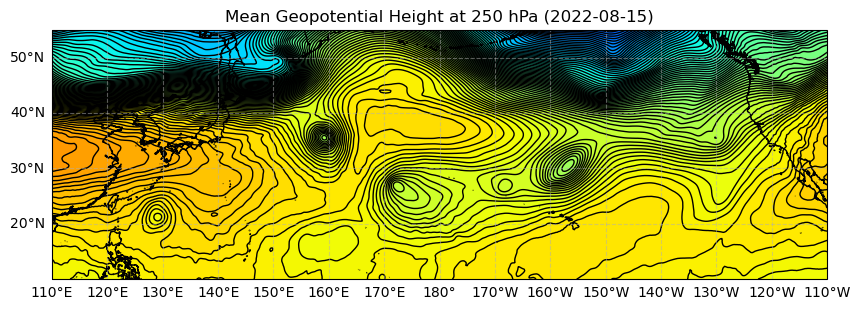

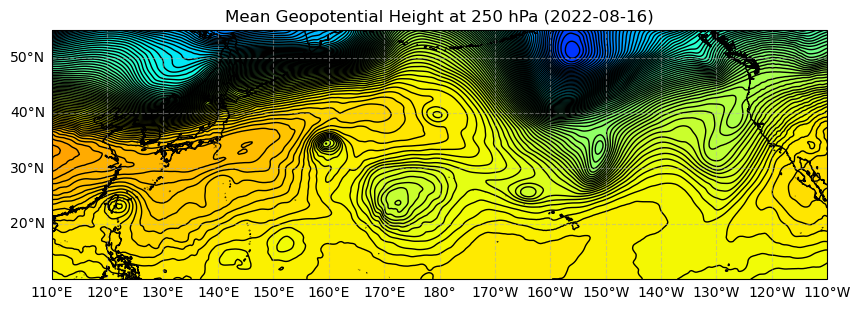

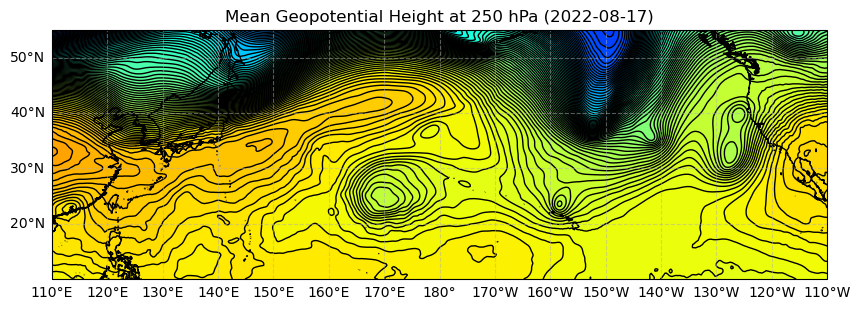

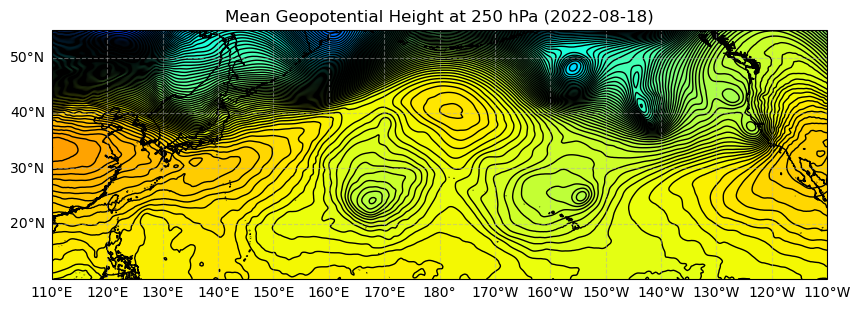

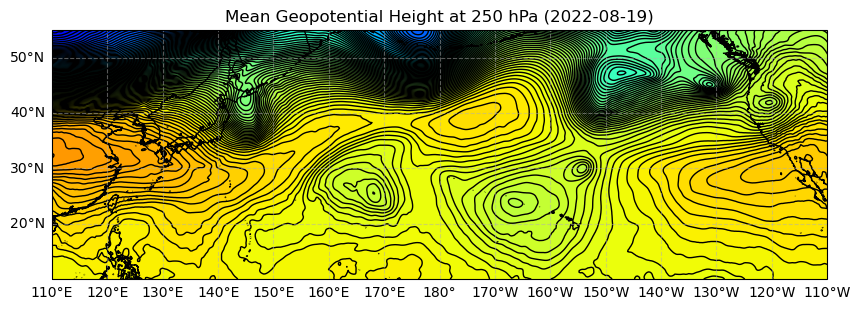

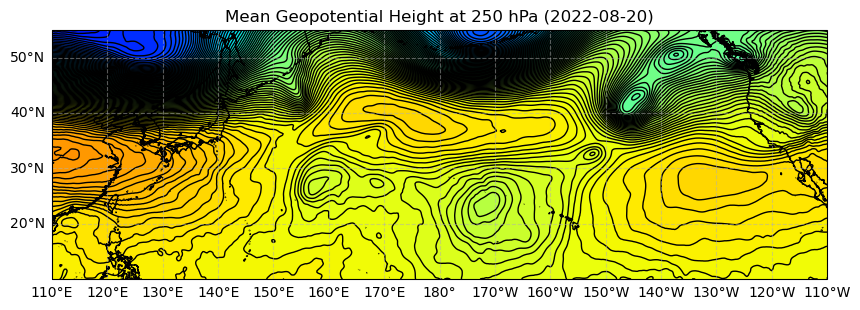

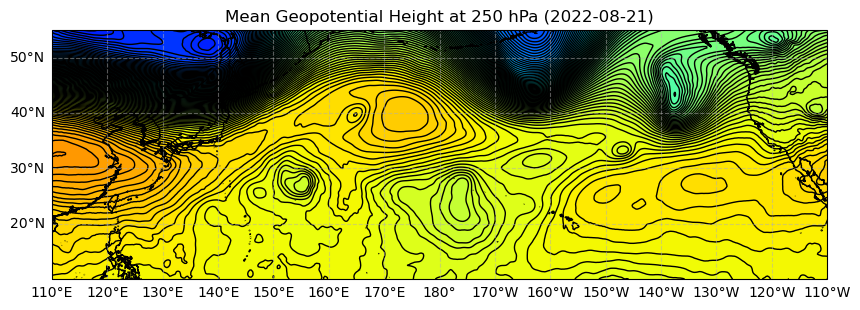

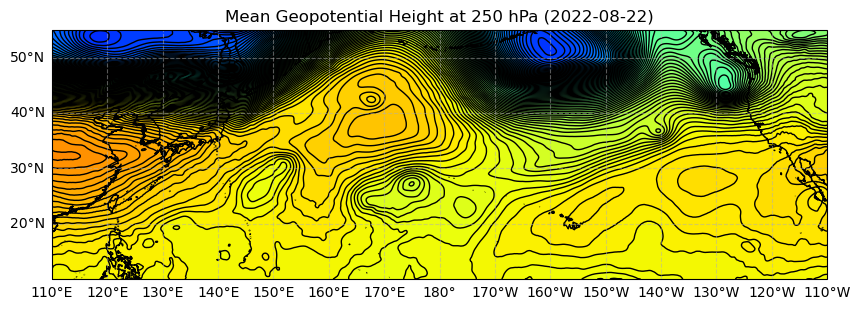

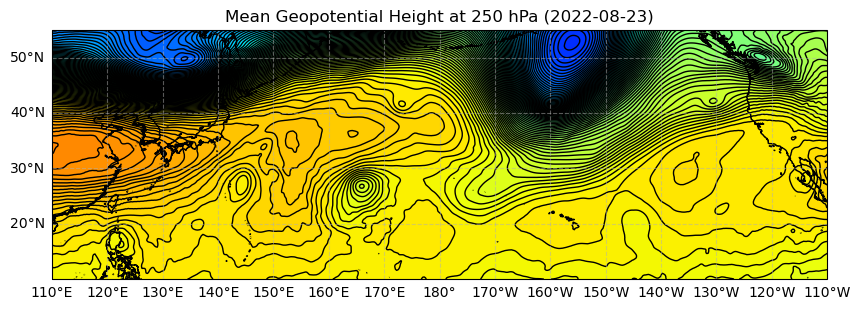

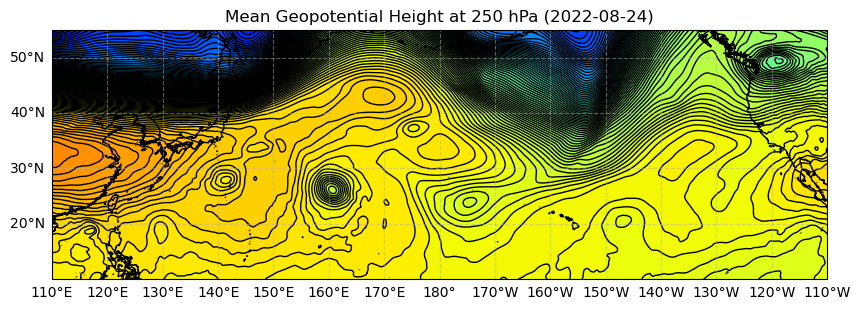

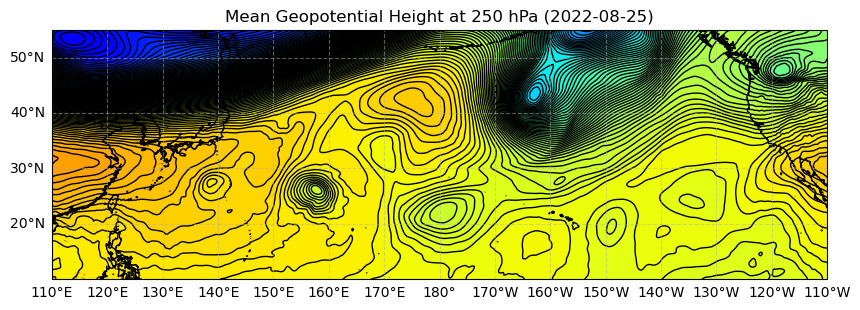

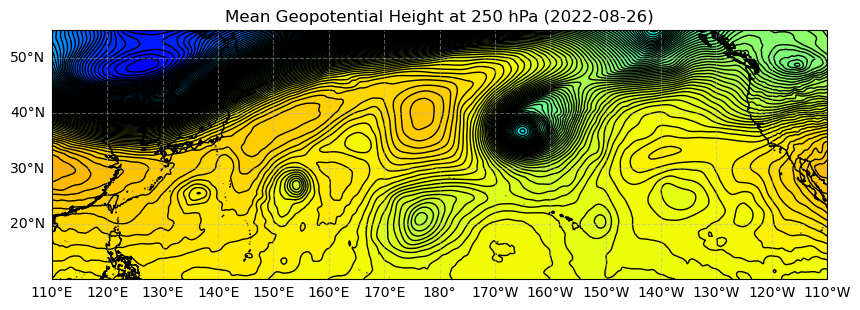

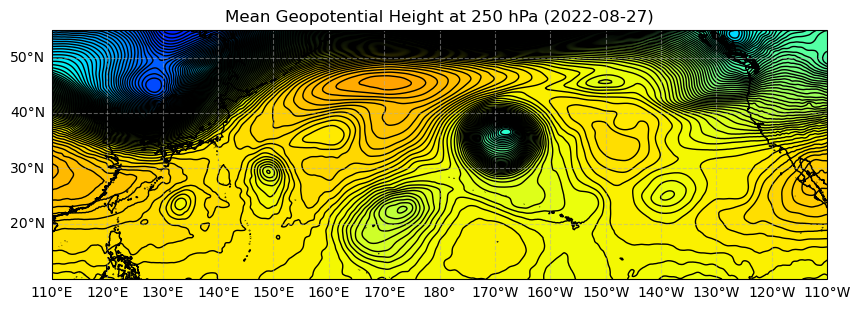

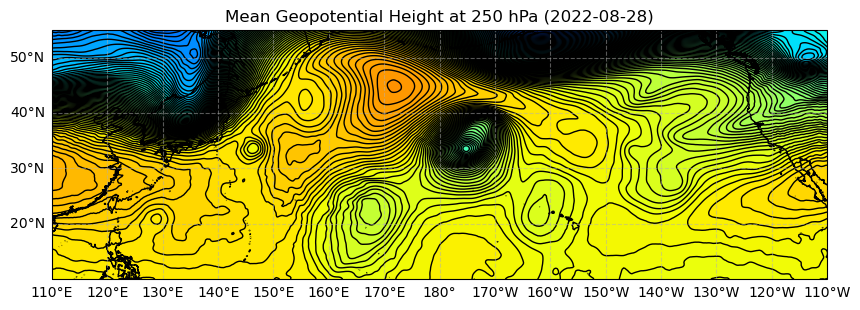

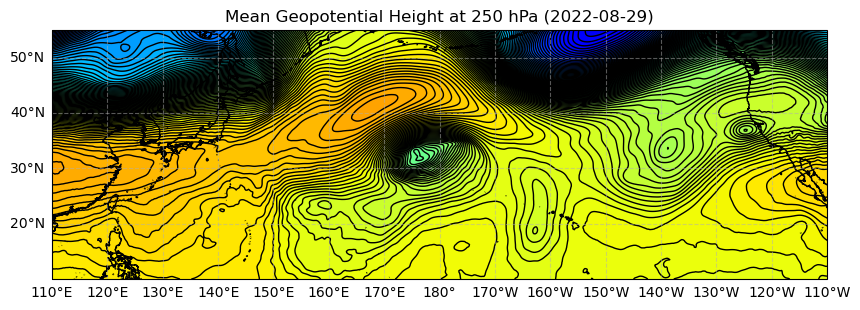

In [3]:
import datetime
G = 9.80665

ds_part = ds[var].sel(pressure_level=250).sel(latitude=slice(55, 10), longitude=slice(110, 280))/G
lon_grid, lat_grid = np.meshgrid(ds_part.longitude.values, ds_part.latitude.values)

key_time = datetime.datetime(2022, 8, 15, 0)
for i in range(15):
    analysis_time = key_time + timedelta(days = i)
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree(180)})
    ax.coastlines("10m")
    ax.set_extent([290, 430, 10, 55], crs=ccrs.PlateCarree(180))
    cax = ax.contourf(lon_grid, lat_grid, ds_part.sel(valid_time = analysis_time), levels = np.arange(10000, 11500, 10), cmap='jet', transform=ccrs.PlateCarree(), linewidths=1)
    cax = ax.contour(lon_grid, lat_grid, ds_part.sel(valid_time = analysis_time), levels = np.arange(10000, 11500, 10), colors='black', transform=ccrs.PlateCarree(), linewidths=1)
    ax.set_title(f'Mean Geopotential Height at 250 hPa ({analysis_time.strftime("%Y-%m-%d")})')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha = 0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 171, 10))
    gl.ylocator = mticker.FixedLocator(np.arange(10, 56, 10))
    plt.show()
